# 前與後處理程式彙整

## 匯入函式庫

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## 前處理
### 波浪參數輸入與 `endTime` 計算

為確保左側邊界初次生成之水波得以抵達右側邊界，並在水槽中達到穩定之週期運動，建議計算時間可讓此水波之前進距離為水槽長度的 2 倍，並視計算結果再做調整。設

- 水槽長度 $l_x$
- 波長 $L$
- 波週期 $T$

則計算終止時間 `endTime` 為

$$
\mathrm{endTime} = 2\,\left(\frac{l_x}{L}\right)\,T
$$

此外，亦須輸入浮體半寬度 `bodyHalfWidth` 及浮體重心位置 `coM`, 以便後續計算。

In [2]:
# 輸入波浪參數與水槽長度
waveHeight     = 0.0787    # 波高 (m)
wavePeriod     = 2.374     # 波週期 (s)
waveLength     = 4.9428    # 波長 (m)
wavePhaseDeg   = 0.0       # Incident wave phase φ_η (deg) at the body reference; 0 means η(t)=a cos(ωt)
tankLength     = 10.0      # 水槽長度 (固定值) (m)
bodyHalfWidth  = 0.236     # 浮體半寬度 (固定值) (m)
coM            = -0.0126   # 浮體重心位置 (固定值) (m)

endTime = 2 * (tankLength/waveLength) * wavePeriod  # 模擬結束時間 (s)
print(f"endTime: {round(endTime,1)} s")

endTime: 9.6 s


## 後處理

### 波高紀錄

波高計 (Wave Gauge, WG) 之位置，可於 `controlDict` 中的 `functions` 設置。例如設定 6 個波高計，其 x 座標分別為
-2.74, -0.05, 0.07, 0.55, 1.9, 2.9 m:

    interfaceHeight1
    {
        type            interfaceHeight;
    
        libs            ("libfieldFunctionObjects.so");
        
        locations       ((-2.74 0 0) (-0.05 0 0) (0.07 0 0) (0.55 0 0) (1.9 0 0) (2.9 0 0));
        alpha           alpha.water;
        
        writeControl   timeStep;
        writeInterval  5;
    }



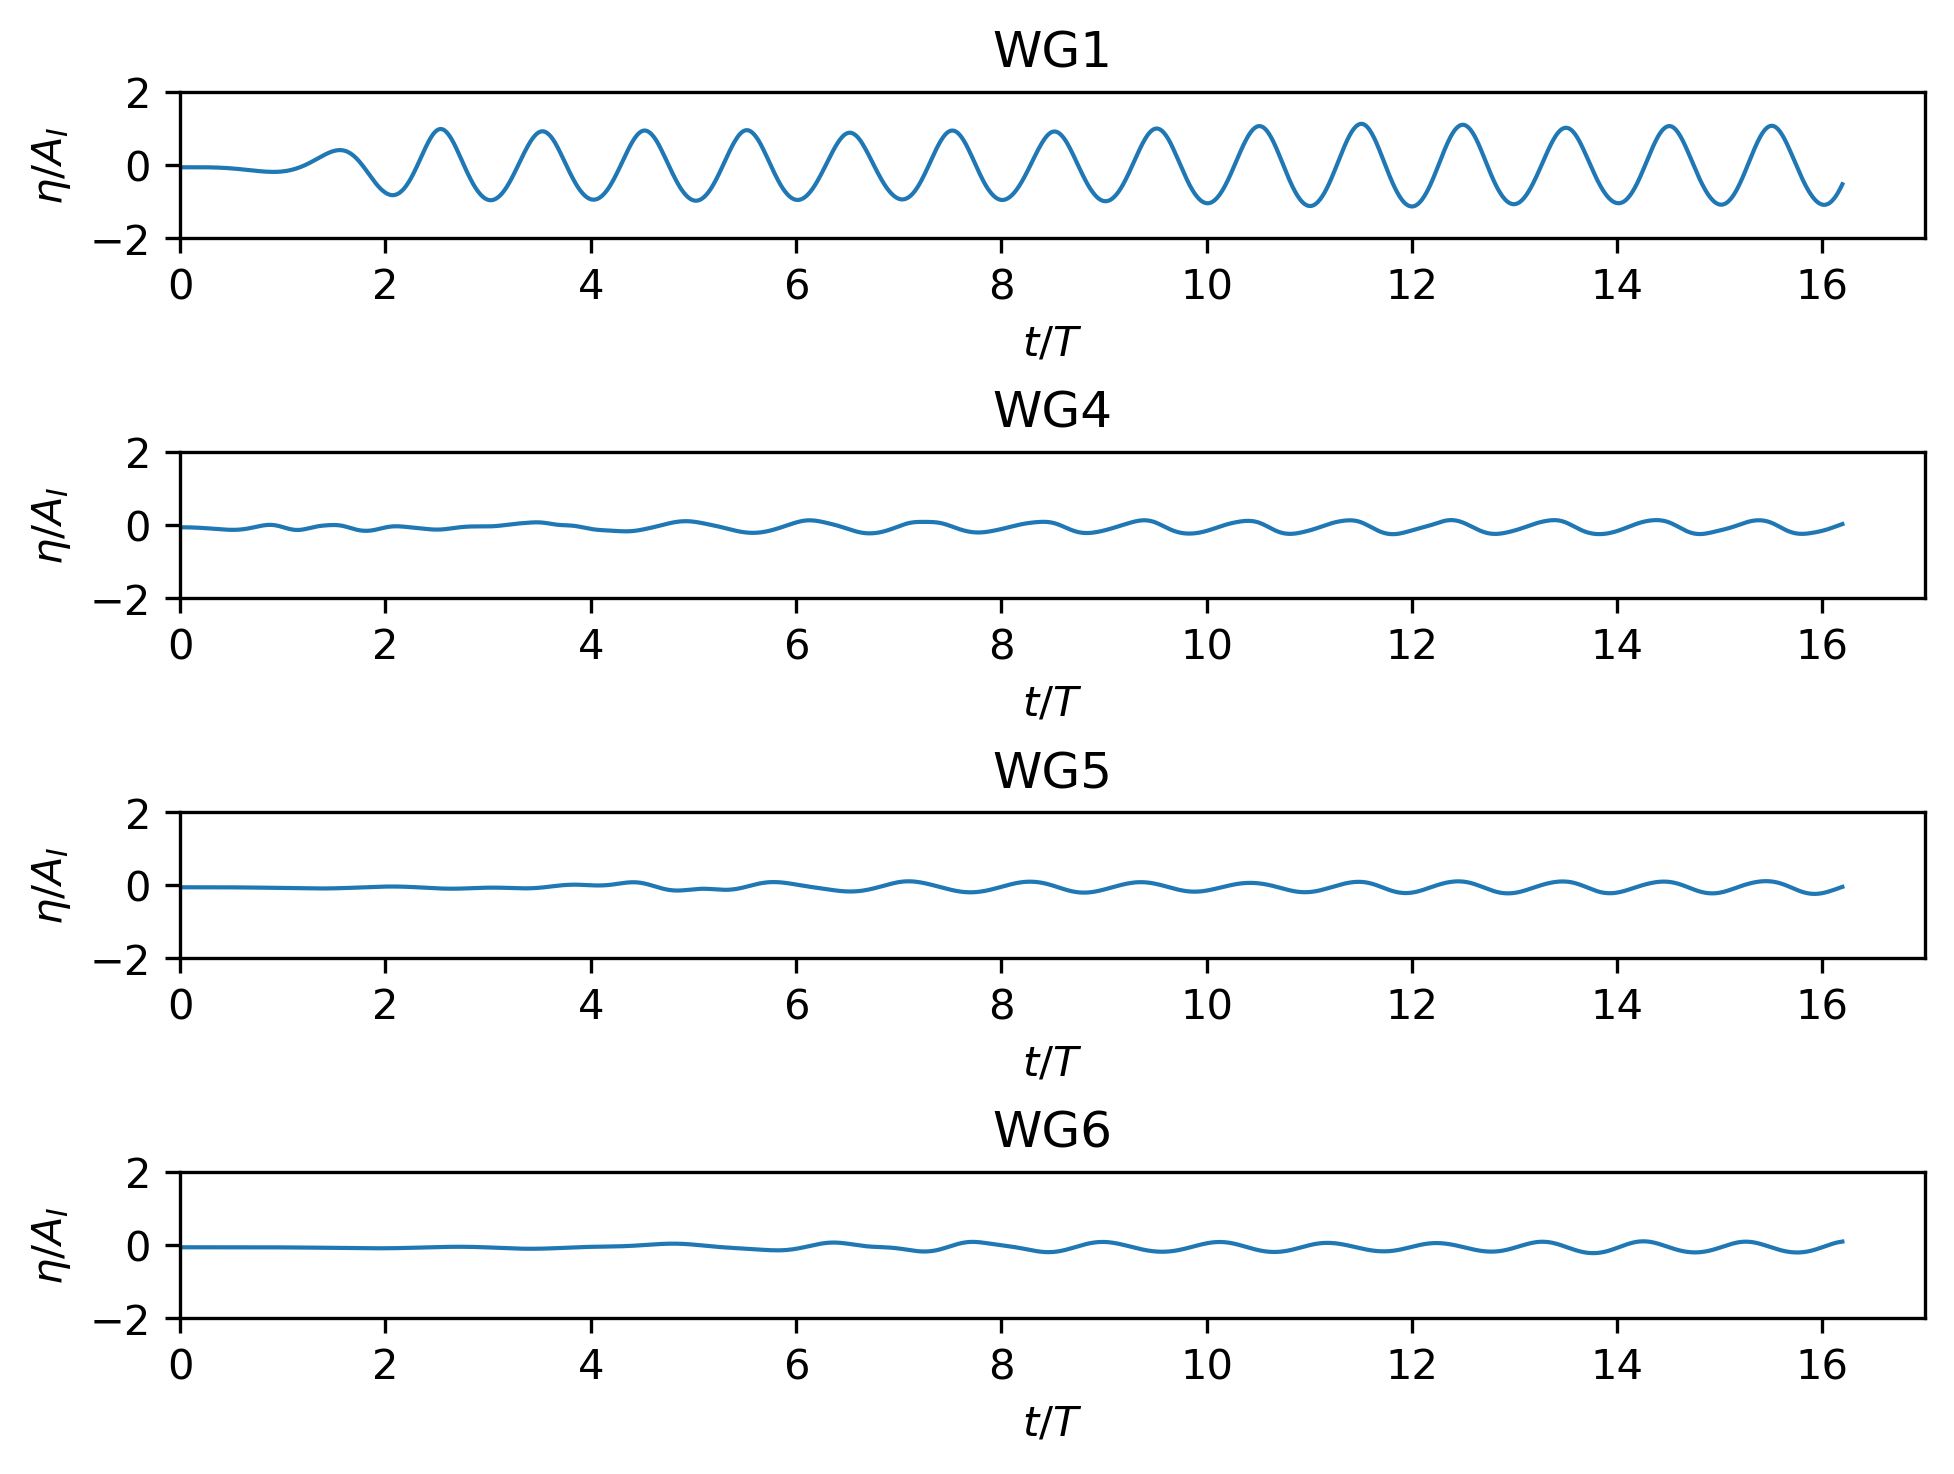

In [3]:
(time,alpha1,height1,alpha2,height2,alpha3,height3,alpha3,height4,alpha5,height5,\
 alpha6,height6) = np.loadtxt('./postProcessing/interfaceHeight1/0/height.dat',unpack=True)

# Set figure and axes ...
fig1, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, dpi=300, layout='constrained')

# Plot ...
ax1.plot(time/wavePeriod, height1/(waveHeight/2), label="labels", linewidth=1)
ax1.set_xlabel(r'$t/T$')
ax1.set_ylabel(r'$\eta/A_I$');
ax1.set_xlim(0,np.ceil(time[-1]/wavePeriod))
ax1.set_ylim(-2,2)
ax1.set_title("WG1")

ax2.plot(time/wavePeriod, height4/(waveHeight/2), label="labels", linewidth=1)
ax2.set_xlabel(r'$t/T$')
ax2.set_ylabel(r'$\eta/A_I$');
ax2.set_xlim(0,np.ceil(time[-1]/wavePeriod))
ax2.set_ylim(-2,2)
ax2.set_title("WG4")

ax3.plot(time/wavePeriod, height5/(waveHeight/2), label="labels", linewidth=1)
ax3.set_xlabel(r'$t/T$')
ax3.set_ylabel(r'$\eta/A_I$');
ax3.set_xlim(0,np.ceil(time[-1]/wavePeriod))
ax3.set_ylim(-2,2)
ax3.set_title("WG5")

ax4.plot(time/wavePeriod, height6/(waveHeight/2), label="labels", linewidth=1)
ax4.set_xlabel(r'$t/T$')
ax4.set_ylabel(r'$\eta/A_I$');
ax4.set_xlim(0,np.ceil(time[-1]/wavePeriod))
ax4.set_ylim(-2,2)
#ax4.set_xlim(0,11)
#ax4.set_ylim(-0.1,0.1)
ax4.set_title("WG6")

# Legends
#ax1.legend()
# Show the figure
plt.show()
 
fig1.savefig('./Plots/height_1.pdf', transparent=False, bbox_inches='tight')

## 浮體 3DoF 運動位移

### 擷取 3DoF 位移量

若是使用 Overset Mesh 計算，無法在 `controlDict` 中設定 3DoF 位移量的輸出。須於計算完後再進行後處理，從 `log.overInterDyMFoam` 中擷取出位移量。

將 `log.overInterDyMFoam` 複製到 `Plots` 資料夾中，並在其中新增資料夾 `logs`。第一次執行時需設定 script 的權限：

    chmod u+x extractMulti.sh

使用以下指令，即可擷取出重心之位移量 (`t_vs_CoM`)、各 DoF 之旋轉角度 (`t_vs_orientation`)、速度向量 (`t_vs_linearV`) 以及角速度 (`t_vs_angularV`)，存在資料夾 `logs` 中:

    ./extractMulti.sh log.overInterDyMFoam

### 擷取 3DoF 位移量指令串

以上的指令與處理，執行下列的程式段即可完成：

In [4]:
import subprocess

subprocess.run("cp ./log.overInterDyMFoam ./Plots/log.overInterDyMFoam", shell=True)
subprocess.run("mkdir -p ./Plots/logs", shell=True)
subprocess.run("chmod u+x ./Plots/extractMulti.sh", shell=True)
subprocess.run("cd ./Plots && ./extractMulti.sh ./log.overInterDyMFoam", shell=True)

nOuterCorrector = 10569 / 10569 = 1


CompletedProcess(args='cd ./Plots && ./extractMulti.sh ./log.overInterDyMFoam', returncode=0)

### 3DoF 位移繪圖

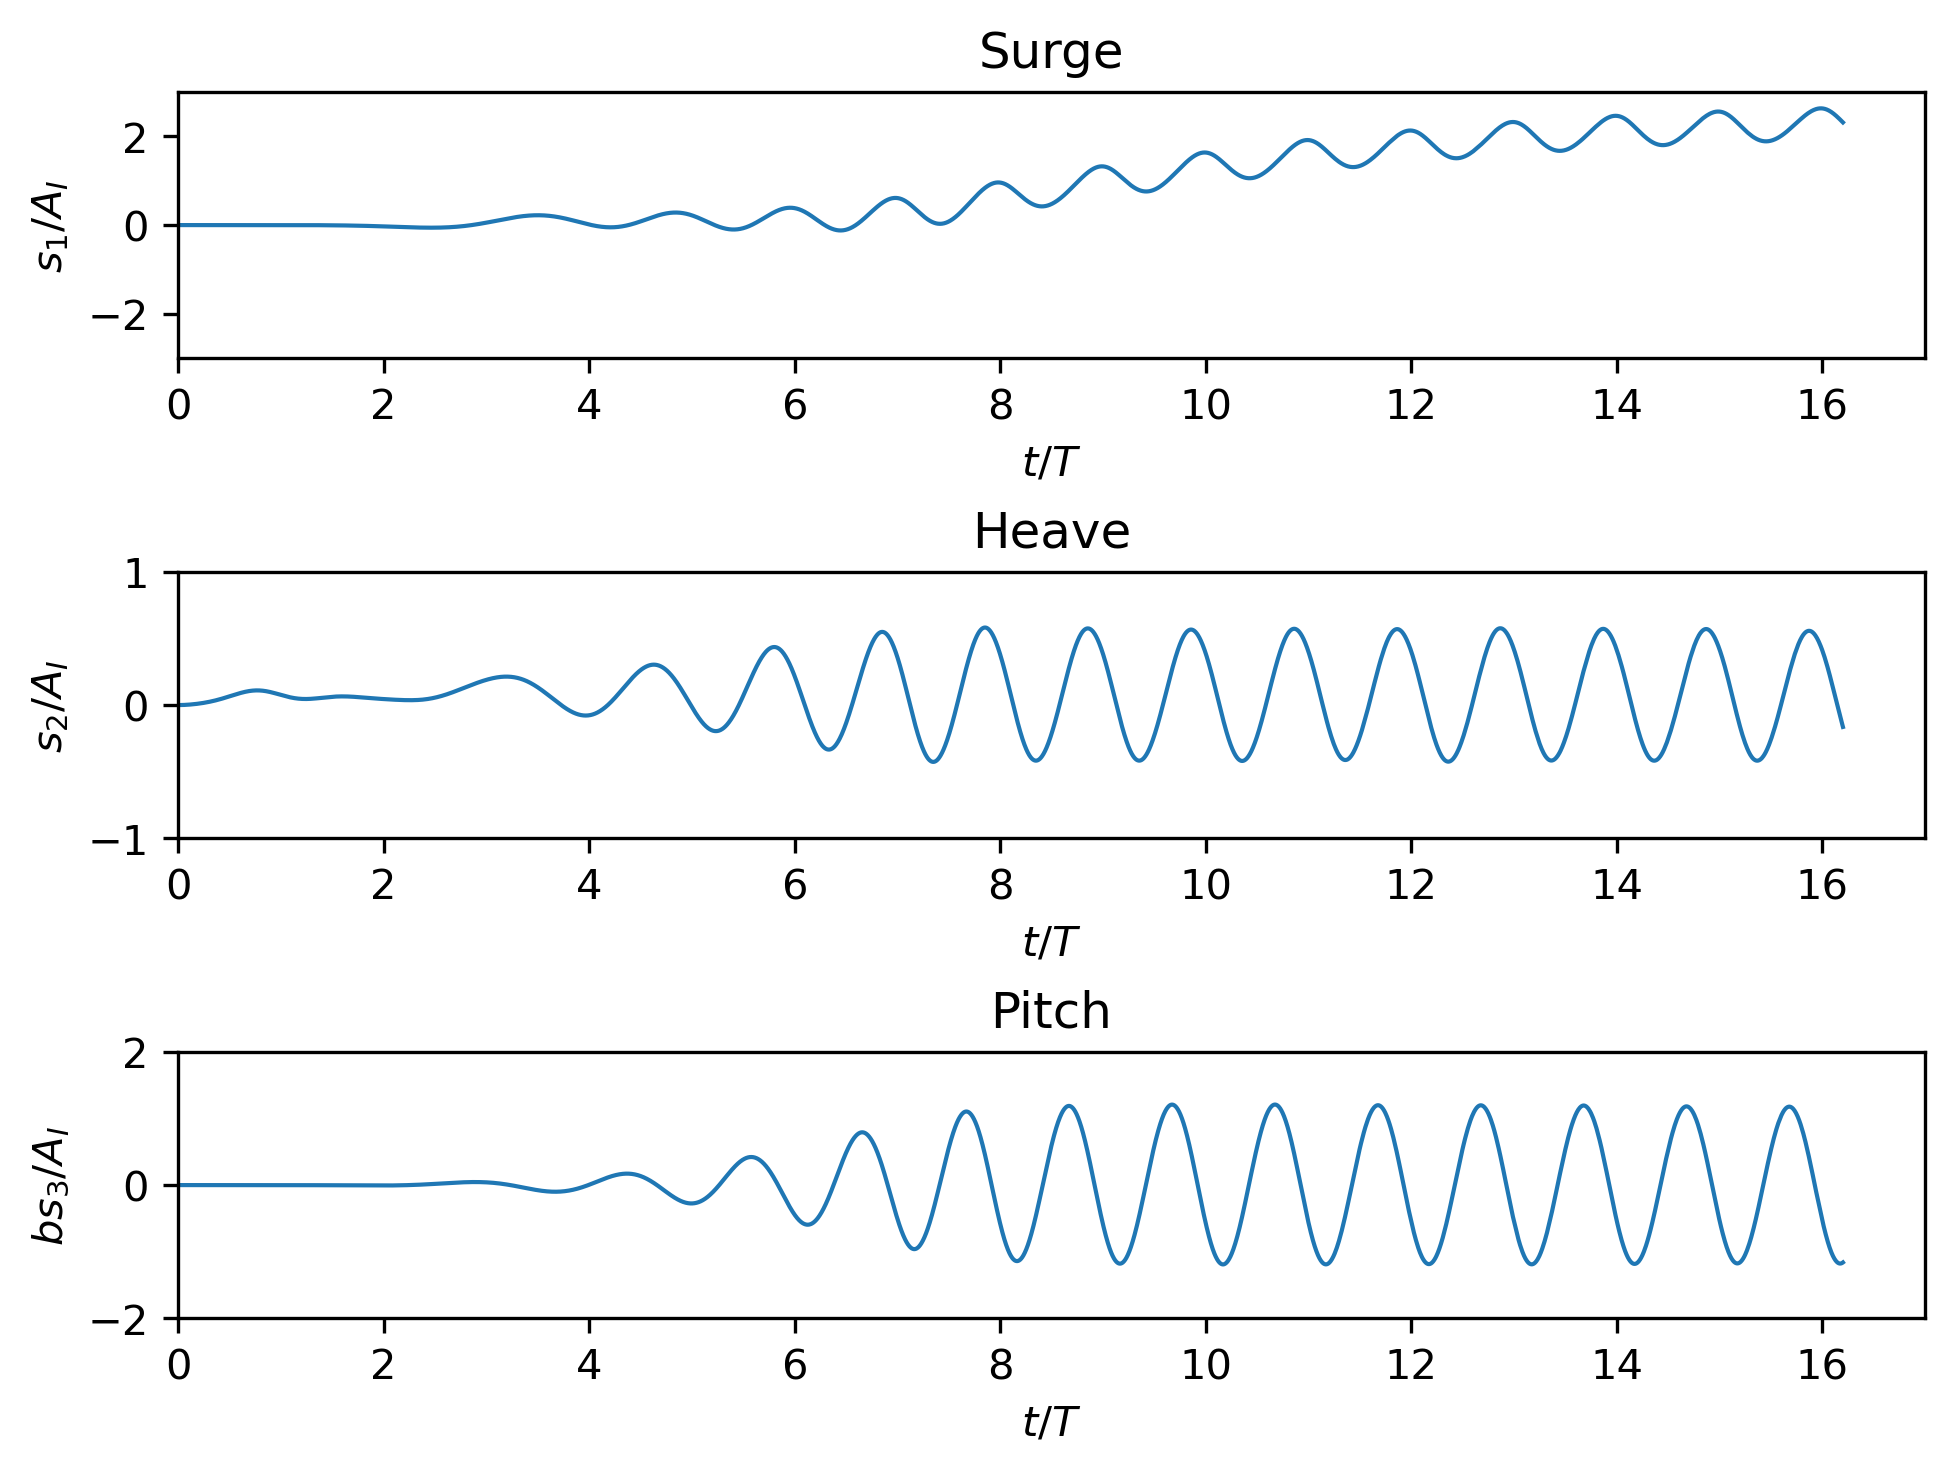

In [5]:
(time, surge, ymotion, heave) = np.loadtxt('./Plots/logs/t_vs_CoM', unpack=True)
(time2, y1, y2, y3, y4, y5, y6, y7, y8, y9) = np.loadtxt('./Plots/logs/t_vs_orientation', unpack=True)

# Pitch (deg) reconstructed from rotation matrix using atan2 for signed, continuous angle.
# Assume y1..y9 correspond to rotation matrix R in row-major order:
# R = [[y1, y2, y3],
#      [y4, y5, y6],
#      [y7, y8, y9]]
R11, R21, R31 = y1, y4, y7
pitch_rad = np.arctan2(-R31, np.sqrt(R11**2 + R21**2))  # ZYX convention
pitch_deg = np.degrees(pitch_rad)

heave = heave - coM  # Adjust heave to body reference point at z=0

# Set figure and axes ...
fig1, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=300, layout='constrained')

# Plot ...
ax1.plot(time/wavePeriod, surge/(waveHeight/2), label="labels", linewidth=1)
ax1.set_xlabel(r'$t/T$')
ax1.set_ylabel(r'$s_1/A_I$')
ax1.set_xlim(0,np.ceil(time[-1]/wavePeriod))
ax1.set_ylim(-3,3)
ax1.set_title("Surge")

ax2.plot(time/wavePeriod, heave/(waveHeight/2), label="labels", linewidth=1)
ax2.set_xlabel(r'$t/T$')
ax2.set_ylabel(r'$s_2/A_I$')
ax2.set_xlim(0,np.ceil(time[-1]/wavePeriod))
ax2.set_ylim(-1,1)
ax2.set_title("Heave")

ax3.plot(time2/wavePeriod, pitch_rad*bodyHalfWidth/(waveHeight/2), label="labels", linewidth=1)
ax3.set_xlabel(r'$t/T$')
ax3.set_ylabel(r'$bs_3/A_I$')
ax3.set_xlim(0,np.ceil(time[-1]/wavePeriod))
ax3.set_ylim(-2,2)
ax3.set_title("Pitch")

# Legends
#ax1.legend()
# Show the figure
plt.show()

fig1.savefig('./Plots/bodyMotion.pdf', transparent=False, bbox_inches='tight')

### 利用快速傅立葉轉換 (FFT) 與最小平方法擬合計算 RAO

設定 `N_CYCLES` 數值為進行 FFT 之資料週期數，從終止時間往回算。建議設定 `N_CYCLES` 至少等於 3:

    N_CYCLES = 3

並須檢查擬合成果是否合理。若擬合結果不佳，代表 `endTime` 不夠長，需重新計算。


[RAO] Results (surge and heave are normalized by a = H/2, pitch is normalized by a/b):
  Incident: H = 0.0393 m, a = 0.01965 m, T = 0.895 s, f = 1.11732 Hz, φ_η = 0.000 deg
  Surge : |RAO| = 0.378141 m/m,  ∠RAO = -13.237 deg  (fit amp = 0.00743047 m)
  Heave : |RAO| = 0.492532 m/m,  ∠RAO = -46.776 deg  (fit amp = 0.00967826 m)
  Pitch : |RAO| = 1.18429 m/m, ∠RAO = -116.364 deg  (fit amp = 5.6498 deg)

[RAO] Frequency check (steady dominant vs theory 1/T):
  Surge FFT(main): f_meas = 1.20135 Hz  |  f_theory = 1.11732 Hz  |  Δf = 8.403e-02 Hz  (7.520%)
  Heave FFT(main): f_meas = 1.20135 Hz  |  f_theory = 1.11732 Hz  |  Δf = 8.403e-02 Hz  (7.520%)
  Pitch FFT(main): f_meas = 1.20135 Hz  |  f_theory = 1.11732 Hz  |  Δf = 8.403e-02 Hz  (7.520%)
[RAO] Saved RAO_single_case.csv

Dominant frequencies and amplitudes (single-sided):
  Surge: f1 = 1.20135 Hz, A1 = 0.00654762 m
  Heave: f1 = 1.20135 Hz, A1 = 0.0095499 m
  Pitch: f1 = 1.20135 Hz, A1 = 5.60201 deg


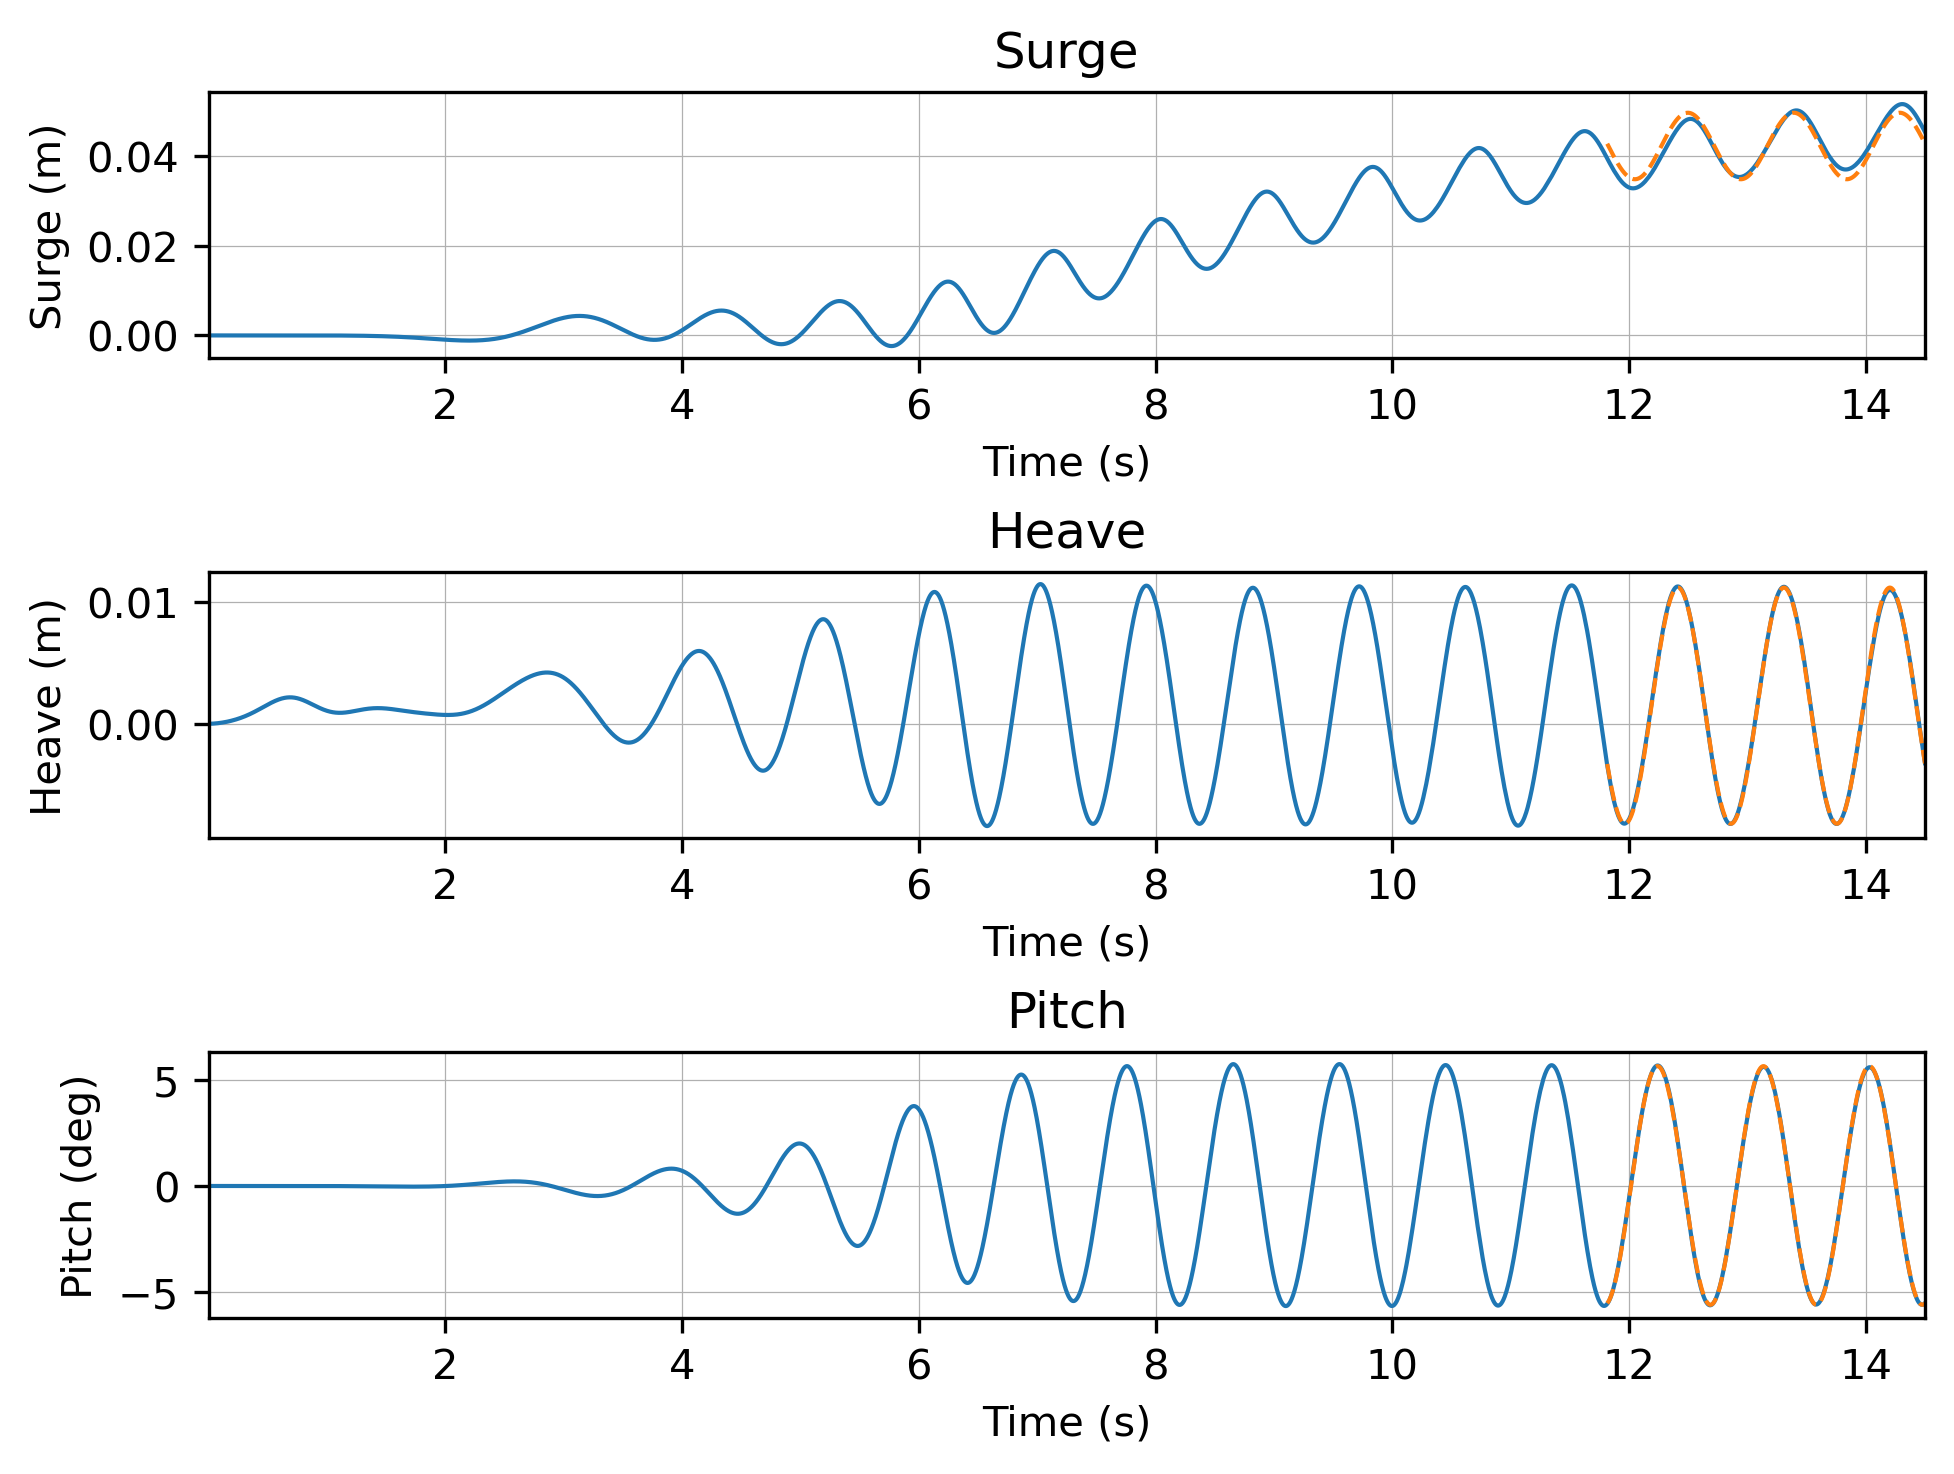

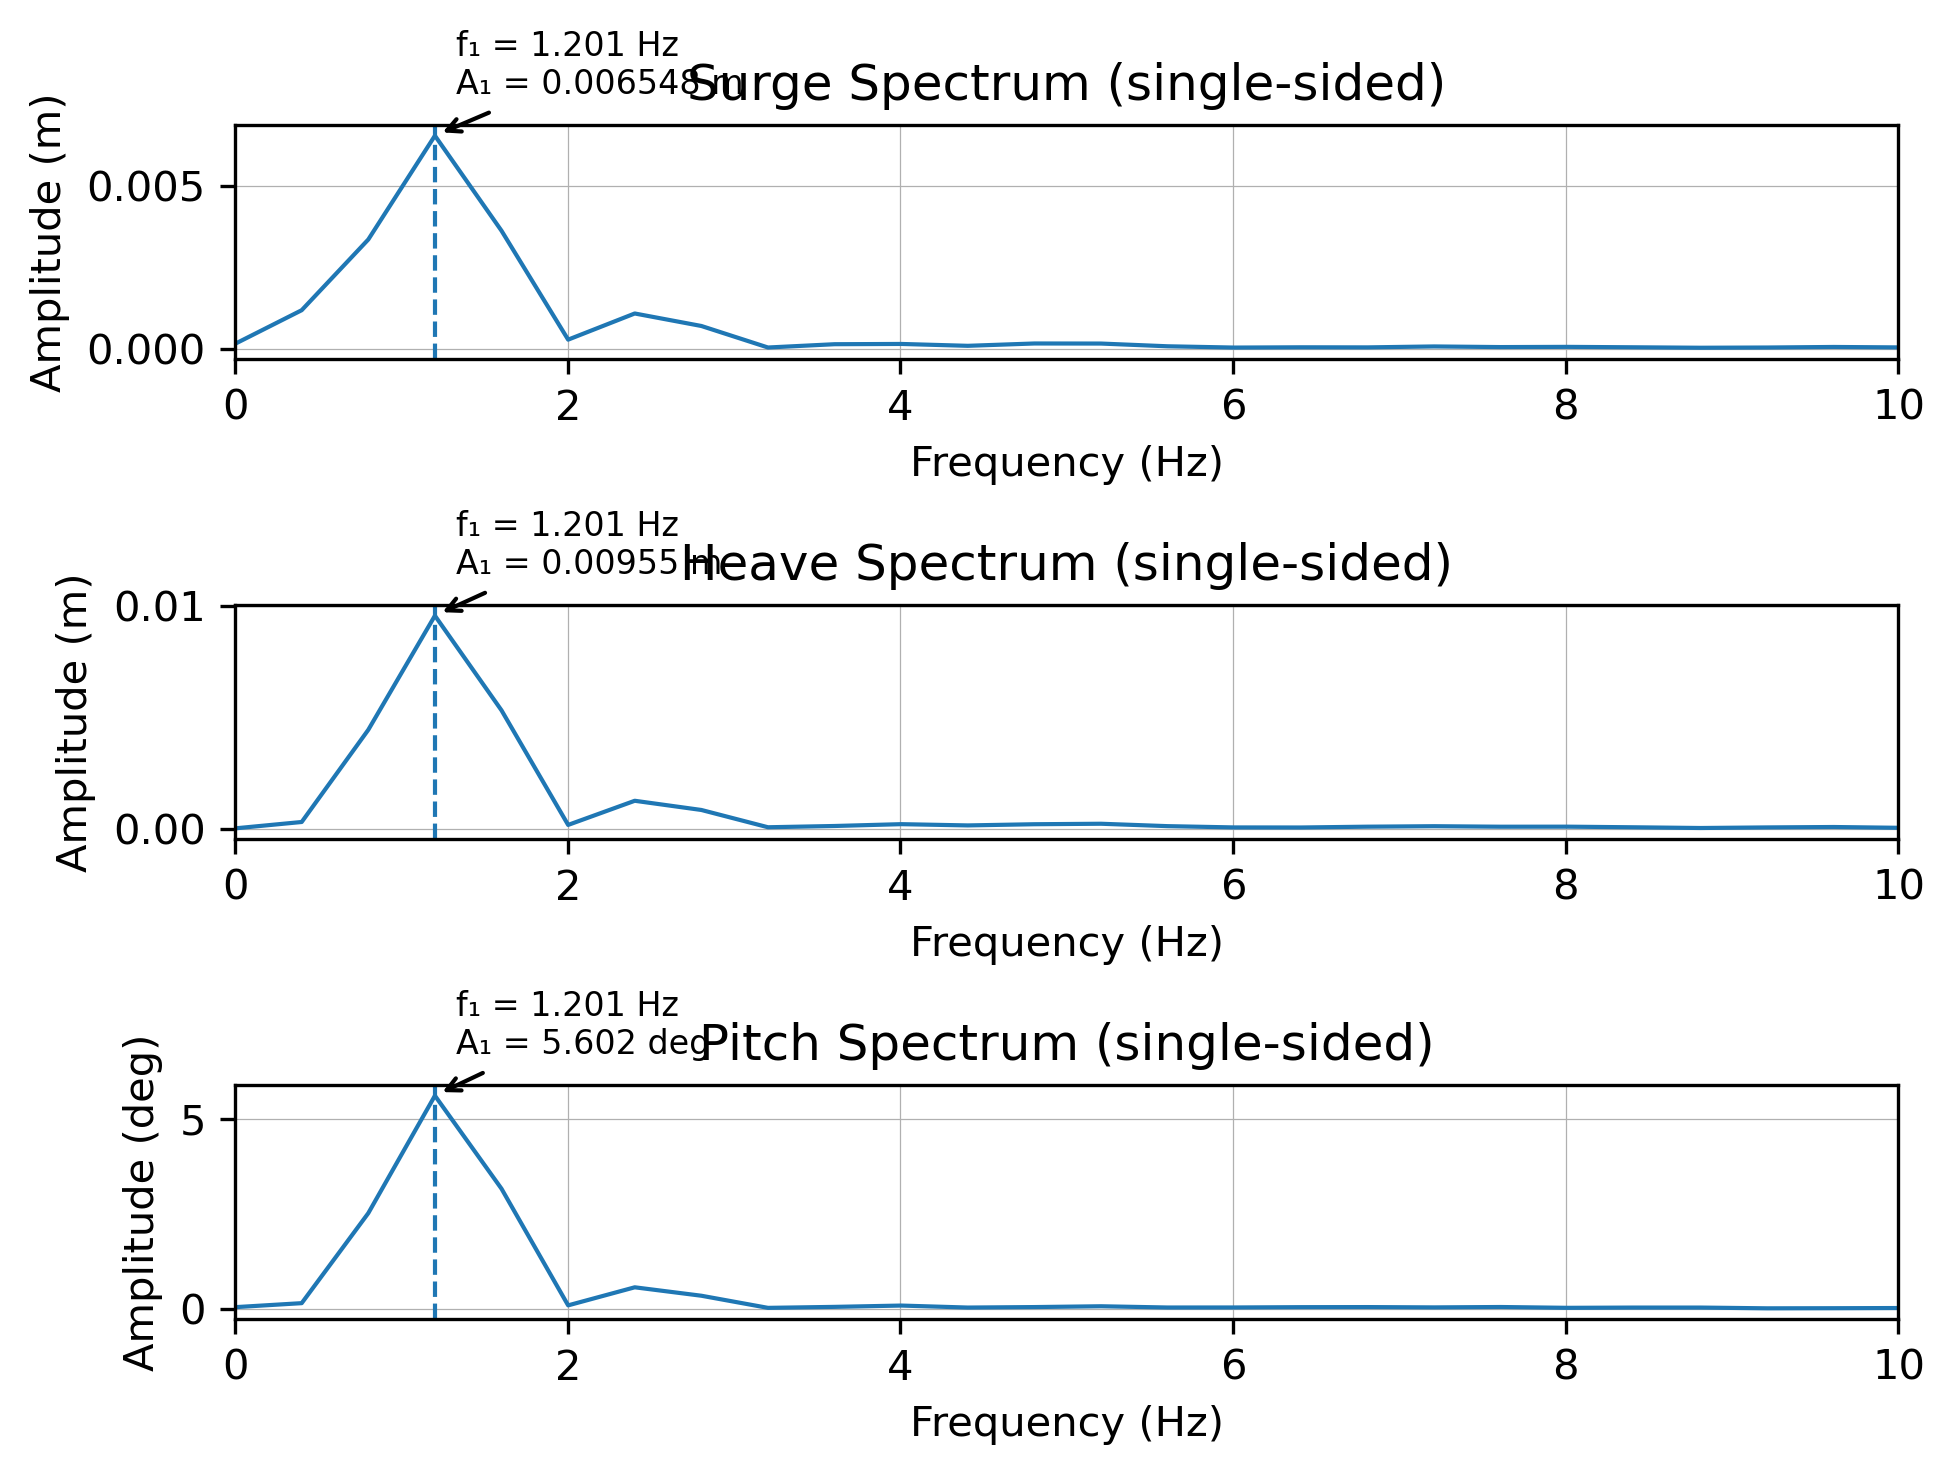

In [6]:
# === Simplified FFT window configuration ===
# Use ONLY the last N_CYCLES cycles (from the end) to compute FFT.
# Reference frequency is the theoretical 1/wavePeriod; if unavailable, fall back to a coarse estimate.
N_CYCLES = 3
RMS_TOL = 0.05
CONSEC_WINDOWS = 3
CYCLES_PER_WINDOW = 1.0
HOP_FRAC = 0.25

def _rms(x: np.ndarray) -> float:
    x = np.asarray(x)
    if x.size == 0:
        return 0.0
    x = x - x.mean()
    return float(np.sqrt(np.mean(x * x)))

def dominant_frequency_estimate(time, signal):
    """Coarse dominant frequency estimate from the whole record (robust to small
    transients). Returns f_peak (Hz) or 0.0 if not resolvable.
    """
    time = np.asarray(time).ravel()
    signal = np.asarray(signal).ravel()
    if time.size < 2 or signal.size < 2:
        return 0.0
    dt = float(np.median(np.diff(time)))
    N = signal.size
    x = signal - np.mean(signal)
    w = np.hanning(N)
    cg = w.mean() if w.mean() != 0 else 1.0
    X = np.fft.rfft(x * w)
    freq = np.fft.rfftfreq(N, dt)
    amp = (2.0 / (N * cg)) * np.abs(X)
    if amp.size <= 1:
        return 0.0
    idx_peak = int(np.argmax(amp[1:])) + 1
    return float(freq[idx_peak])

def find_steady_segment(time, signal, f_est,
                        rms_tol=RMS_TOL,
                        cycles_per_window=CYCLES_PER_WINDOW,
                        hop_frac=HOP_FRAC,
                        consecutive=CONSEC_WINDOWS):
    """Return (t_ss, idx_ss): steady-state start time/index using sliding RMS.
    We slide a window of ~ one period and look for `consecutive` windows whose
    RMS changes by less than `rms_tol`.
    If detection fails, return the original start.
    """
    time = np.asarray(time).ravel()
    signal = np.asarray(signal).ravel()
    if time.size < 4 or f_est <= 0:
        return time[0], 0
    dt = float(np.median(np.diff(time)))
    T = 1.0 / f_est
    win_len = max(4, int(round(cycles_per_window * T / dt)))
    hop = max(1, int(round(hop_frac * win_len)))
    N = signal.size
    # Guard: if window bigger than data, bail out
    if win_len >= N:
        return time[0], 0
    # Precompute window RMS along the record
    rms_vals = []
    starts = []
    for start in range(0, N - win_len + 1, hop):
        seg = signal[start:start + win_len]
        rms_vals.append(_rms(seg))
        starts.append(start)
    # Look for `consecutive` windows meeting tolerance
    for k in range(consecutive, len(rms_vals)):
        ok = True
        for j in range(k - consecutive + 1, k + 1):
            r0 = rms_vals[j - 1]
            r1 = rms_vals[j]
            denom = max(abs(r0), 1e-16)
            if abs(r1 - r0) / denom > rms_tol:
                ok = False
                break
        if ok:
            idx_ss = starts[k - consecutive + 1]
            return time[idx_ss], idx_ss
    # Fallback: no steady region found
    return time[0], 0

def trim_to_n_cycles_from_end(time, signal, f, n_cycles):
    """Trim arrays to the last n_cycles based on frequency f (Hz)."""
    if f <= 0:
        return time, signal
    T = 1.0 / f
    t_end = time[-1]
    t_start = t_end - n_cycles * T
    mask = time >= t_start
    return time[mask], signal[mask]

# === Fit only the last N cycles at frequency f ===
def fit_main_sinusoid_last_cycles(time, signal, f, n_cycles):
    """Fit a sinusoid at frequency f on ONLY the last n_cycles of (time, signal).
    Returns (t_seg, yhat_seg, amplitude, phase).
    """
    time = np.asarray(time).ravel()
    signal = np.asarray(signal).ravel()
    if time.size < 2 or signal.size < 2 or not (isinstance(f, (int, float)) and f > 0):
        return time[-0:0], np.zeros(0), 0.0, 0.0
    t_seg, y_seg = trim_to_n_cycles_from_end(time, signal, f, int(n_cycles))
    if t_seg.size < 2:
        return t_seg, np.zeros_like(t_seg), 0.0, 0.0
    w = 2.0 * np.pi * float(f)
    C = np.cos(w * t_seg)
    S = np.sin(w * t_seg)
    M = np.column_stack([np.ones_like(t_seg), C, S])
    coeffs, *_ = np.linalg.lstsq(M, y_seg, rcond=None)
    c, a, b = coeffs
    R = float(np.sqrt(a*a + b*b))
    phi = float(np.arctan2(b, a))  # y ≈ c + R*cos(w t - phi)
    yhat_seg = c + a*np.cos(w * t_seg) + b*np.sin(w * t_seg)
    return t_seg, yhat_seg, R, phi

# === Fit main-frequency sinusoid for overlay ===
def fit_main_sinusoid(time, signal, f, use_steady=True):
    """Least-squares fit of a sinusoid at frequency f to (time, signal).
    Model: y(t) ≈ c + a*cos(2π f t) + b*sin(2π f t)
    Returns (y_hat_full, idx_ss, amplitude, phase), where phase φ satisfies
    R*cos(2π f t - φ) with R = sqrt(a^2+b^2) and φ = atan2(b, a).
    If use_steady is True, the fit is done over the detected steady segment
    (same criteria as FFT steady-state) and then evaluated on the *full* time
    vector so it can be overlaid for comparison.
    """
    time = np.asarray(time).ravel()
    signal = np.asarray(signal).ravel()
    if time.size < 2 or signal.size < 2:
        return np.full_like(time, np.nan, dtype=float), 0, 0.0, 0.0
    f_use = float(f) if f and f > 0 else dominant_frequency_estimate(time, signal)
    idx_ss = 0
    if use_steady and f_use > 0:
        _, idx_ss = find_steady_segment(time, signal, f_use)
    t_fit = time[idx_ss:]
    y_fit = signal[idx_ss:]
    if t_fit.size < 2:
        return np.full_like(time, np.nan, dtype=float), 0, 0.0, 0.0
    w = 2.0 * np.pi * f_use
    C = np.cos(w * t_fit)
    S = np.sin(w * t_fit)
    # Design matrix: [1, cos, sin]
    M = np.column_stack([np.ones_like(t_fit), C, S])
    coeffs, *_ = np.linalg.lstsq(M, y_fit, rcond=None)
    c, a, b = coeffs
    R = float(np.sqrt(a*a + b*b))
    phi = float(np.arctan2(b, a))  # y ≈ c + R*cos(w t - phi)
    # Evaluate on full time for overlay
    y_hat_full = c + a*np.cos(w * time) + b*np.sin(w * time)
    return y_hat_full, idx_ss, R, phi

# === Helper functions ===
def compute_fft(time, signal):
    """Compute single-sided amplitude spectrum using ONLY the last N_CYCLES cycles
    (from the end of the record). Amplitude is in the same units as the input signal.
    """
    # Ensure 1D arrays
    time = np.asarray(time).ravel()
    signal = np.asarray(signal).ravel()

    # Guard: need at least 2 samples
    if time.size < 2 or signal.size < 2:
        return np.array([0.0]), np.array([0.0]), 0.0, 0.0

    # Reference frequency: prefer theoretical 1/T; otherwise coarse estimate
    try:
        f_ref = 1.0 / float(wavePeriod)
    except Exception:
        f_ref = dominant_frequency_estimate(time, signal)
    if not (isinstance(f_ref, (int, float)) and f_ref > 0):
        f_ref = dominant_frequency_estimate(time, signal)

    # Trim to the last N_CYCLES cycles from the end
    n_cycles = int(N_CYCLES) if isinstance(N_CYCLES, (int, float)) and N_CYCLES else 1
    time_fft, sig_fft = trim_to_n_cycles_from_end(time, signal, f_ref, n_cycles)
    if time_fft.size < 2:
        # Fallback: use full record
        time_fft, sig_fft = time, signal

    # Uniform dt from median to be robust to tiny jitter
    dt = float(np.median(np.diff(time_fft)))
    N = sig_fft.size

    # Detrend (remove mean) + Hann window
    x = sig_fft - np.mean(sig_fft)
    w = np.hanning(N)
    cg = w.mean() if w.mean() != 0 else 1.0  # coherent gain of window
    xw = x * w

    # rFFT and single-sided amplitude spectrum
    X = np.fft.rfft(xw)
    freq = np.fft.rfftfreq(N, dt)

    amp = (2.0 / (N * cg)) * np.abs(X)
    # Correct DC term (no doubling)
    if amp.size > 0:
        amp[0] = np.abs(X[0]) / (N * cg)

    # Identify dominant peak excluding DC
    if amp.size > 1:
        idx_peak = int(np.argmax(amp[1:])) + 1
    else:
        idx_peak = 0
    f_peak = float(freq[idx_peak]) if freq.size else 0.0
    amp_peak = float(amp[idx_peak]) if amp.size else 0.0

    return freq, amp, f_peak, amp_peak


def annotate_peak(ax, f_peak, amp_peak, unit):
    ax.axvline(f_peak, linestyle='--', linewidth=1)
    ax.annotate(
        f"f₁ = {f_peak:.4g} Hz\nA₁ = {amp_peak:.4g} {unit}",
        xy=(f_peak, amp_peak), xytext=(5, 10), textcoords='offset points',
        arrowprops=dict(arrowstyle='->', lw=1), fontsize=8
    )


# === Time histories ===
fig1, (ax11, ax12, ax13) = plt.subplots(3, 1, dpi=300, layout='constrained')

ax11.plot(time, surge, linewidth=1)
ax11.set_xlabel('Time (s)')
ax11.set_ylabel('Surge (m)')
ax11.set_xlim(time.min(), time.max())
ax11.set_title('Surge')
ax11.grid(True, linewidth=0.3)

ax12.plot(time, heave, linewidth=1)
ax12.set_xlabel('Time (s)')
ax12.set_ylabel('Heave (m)')
ax12.set_xlim(time.min(), time.max())
ax12.set_title('Heave')
ax12.grid(True, linewidth=0.3)

ax13.plot(time2, pitch_deg, linewidth=1)
ax13.set_xlabel('Time (s)')
ax13.set_ylabel('Pitch (deg)')
ax13.set_xlim(time2.min(), time2.max())
ax13.set_title('Pitch')
ax13.grid(True, linewidth=0.3)


# === FFTs ===
freq_surge, amp_surge, f1_surge, A1_surge = compute_fft(time, surge)
freq_heave, amp_heave, f1_heave, A1_heave = compute_fft(time, heave)
freq_pitch, amp_pitch, f1_pitch, A1_pitch = compute_fft(time2, pitch_deg)

# === Overlay main-frequency sinusoid on time histories using theoretical frequency (1/T) ===
f_theory = 1.0 / float(wavePeriod)

# Surge overlay on last N_CYCLES only
seg_t_surge, seg_yhat_surge, R_surge, phi_surge = fit_main_sinusoid_last_cycles(time, surge, f_theory, N_CYCLES)
if seg_t_surge.size > 1:
    ax11.plot(seg_t_surge, seg_yhat_surge, linestyle='--', linewidth=1)

# Heave overlay on last N_CYCLES only
seg_t_heave, seg_yhat_heave, R_heave, phi_heave = fit_main_sinusoid_last_cycles(time, heave, f_theory, N_CYCLES)
if seg_t_heave.size > 1:
    ax12.plot(seg_t_heave, seg_yhat_heave, linestyle='--', linewidth=1)

# Pitch overlay on last N_CYCLES only
seg_t_pitch, seg_yhat_pitch, R_pitch, phi_pitch = fit_main_sinusoid_last_cycles(time2, pitch_deg, f_theory, N_CYCLES)
if seg_t_pitch.size > 1:
    ax13.plot(seg_t_pitch, seg_yhat_pitch, linestyle='--', linewidth=1)

# === RAO computation (single case) ===
# Use incident Stokes II fundamental amplitude a = H/2 as normalization
inc_amp = 0.5 * float(waveHeight)
inc_phase = np.deg2rad(float(wavePhaseDeg))  # reference η(t)=a cos(ωt - φ_η)

# Guard for zero/near-zero incident amplitude
if inc_amp <= 0:
    print("[RAO] Warning: incident amplitude is non-positive; cannot compute RAO.")
    rao_surge_mag = rao_heave_mag = rao_pitch_mag = np.nan
    rao_surge_phase = rao_heave_phase = rao_pitch_phase = np.nan
else:
    # Convert pitch amplitude to radians for RAO (rad/m)
    R_pitch_rad = np.deg2rad(R_pitch)

    rao_surge_mag = R_surge / inc_amp              # m/m
    rao_heave_mag = R_heave / inc_amp              # m/m
    rao_pitch_mag = R_pitch_rad / inc_amp          # rad/m

    # Phase of RAO = φ_resp - φ_eta
    rao_surge_phase = np.degrees(phi_surge - inc_phase)
    rao_heave_phase = np.degrees(phi_heave - inc_phase)
    rao_pitch_phase = np.degrees(phi_pitch - inc_phase)

# Frequencies for reference
f_incident = 1.0 / float(wavePeriod)

# Print RAO summary
print("\n[RAO] Results (surge and heave are normalized by a = H/2, pitch is normalized by a/b):")
print(f"  Incident: H = {waveHeight:.6g} m, a = {inc_amp:.6g} m, T = {wavePeriod:.6g} s, f = {f_incident:.6g} Hz, φ_η = {wavePhaseDeg:.3f} deg")
print(f"  Surge : |RAO| = {rao_surge_mag:.6g} m/m,  ∠RAO = {rao_surge_phase:.3f} deg  (fit amp = {R_surge:.6g} m)")
print(f"  Heave : |RAO| = {rao_heave_mag:.6g} m/m,  ∠RAO = {rao_heave_phase:.3f} deg  (fit amp = {R_heave:.6g} m)")
print(f"  Pitch : |RAO| = {rao_pitch_mag*bodyHalfWidth:.6g} m/m, ∠RAO = {rao_pitch_phase:.3f} deg  (fit amp = {R_pitch:.6g} deg)")

# === RAO frequency check: measured (steady dominant) vs theory (1/T) ===
print("\n[RAO] Frequency check (steady dominant vs theory 1/T):")
f_theory = 1.0 / float(wavePeriod)

def _freq_check(label, f_meas, f_ref):
    if f_meas is None or not np.isfinite(f_meas) or f_meas <= 0:
        print(f"  {label}: f_meas unavailable")
        return
    df = f_meas - f_ref
    rel = abs(df) / f_ref * 100.0 if f_ref > 0 else np.nan
    print(f"  {label}: f_meas = {f_meas:.6g} Hz  |  f_theory = {f_ref:.6g} Hz  |  Δf = {df:.3e} Hz  ({rel:.3f}%)")

# Use dominant frequencies from steady segments computed above
_freq_check("Surge FFT(main)", f1_surge, f_theory)
_freq_check("Heave FFT(main)", f1_heave, f_theory)
_freq_check("Pitch FFT(main)", f1_pitch, f_theory)

# Save CSV for this case
try:
    import csv
    with open('RAO_single_case.csv', 'w', newline='') as fcsv:
        w = csv.writer(fcsv)
        w.writerow(["quantity","value","unit"]) 
        w.writerow(["H",        f"{waveHeight:.8g}",      "m"]) 
        w.writerow(["a",        f"{inc_amp:.8g}",         "m"]) 
        w.writerow(["T",        f"{wavePeriod:.8g}",      "s"]) 
        w.writerow(["f_inc",    f"{f_incident:.8g}",      "Hz"]) 
        w.writerow(["phi_eta",  f"{wavePhaseDeg:.8g}",    "deg"]) 
        w.writerow(["R_surge",  f"{R_surge:.8g}",         "m"]) 
        w.writerow(["R_heave",  f"{R_heave:.8g}",         "m"]) 
        w.writerow(["R_pitch",  f"{R_pitch:.8g}",         "deg"]) 
        w.writerow(["RAO_surge_mag", f"{rao_surge_mag:.8g}", "m/m"]) 
        w.writerow(["RAO_heave_mag", f"{rao_heave_mag:.8g}", "m/m"]) 
        w.writerow(["RAO_pitch_mag", f"{rao_pitch_mag:.8g}", "rad/m"]) 
        w.writerow(["RAO_surge_phase", f"{rao_surge_phase:.8g}", "deg"]) 
        w.writerow(["RAO_heave_phase", f"{rao_heave_phase:.8g}", "deg"]) 
        w.writerow(["RAO_pitch_phase", f"{rao_pitch_phase:.8g}", "deg"]) 
    print("[RAO] Saved RAO_single_case.csv")
except Exception as e:
    print(f"[RAO] CSV save failed: {e}")

# Optional: legends for clarity
# ax1.legend(["Data", "Main freq fit"], loc="best", fontsize=8)
# ax2.legend(["Data", "Main freq fit"], loc="best", fontsize=8)
# ax3.legend(["Data", "Main freq fit"], loc="best", fontsize=8)

fig2, (bx1, bx2, bx3) = plt.subplots(3, 1, dpi=300, layout='constrained')

bx1.plot(freq_surge, amp_surge, linewidth=1)
bx1.set_xlabel('Frequency (Hz)')
bx1.set_ylabel('Amplitude (m)')
bx1.set_title('Surge Spectrum (single-sided)')
bx1.grid(True, linewidth=0.3)
bx1.set_xlim(0, 10)
annotate_peak(bx1, f1_surge, A1_surge, 'm')

bx2.plot(freq_heave, amp_heave, linewidth=1)
bx2.set_xlabel('Frequency (Hz)')
bx2.set_ylabel('Amplitude (m)')
bx2.set_title('Heave Spectrum (single-sided)')
bx2.grid(True, linewidth=0.3)
bx2.set_xlim(0, 10)
annotate_peak(bx2, f1_heave, A1_heave, 'm')

bx3.plot(freq_pitch, amp_pitch, linewidth=1)
bx3.set_xlabel('Frequency (Hz)')
bx3.set_ylabel('Amplitude (deg)')
bx3.set_title('Pitch Spectrum (single-sided)')
bx3.grid(True, linewidth=0.3)
bx3.set_xlim(0, 10)
annotate_peak(bx3, f1_pitch, A1_pitch, 'deg')

# Optional: limit x-axis to Nyquist or a reasonable max (auto by default)
# for ax in (bx1, bx2, bx3):
#     ax.set_xlim(0, max(ax.get_xlim()[1], 1.0))

# === Print summary to console ===
print('\nDominant frequencies and amplitudes (single-sided):')
print(f"  Surge: f1 = {f1_surge:.6g} Hz, A1 = {A1_surge:.6g} m")
print(f"  Heave: f1 = {f1_heave:.6g} Hz, A1 = {A1_heave:.6g} m")
print(f"  Pitch: f1 = {f1_pitch:.6g} Hz, A1 = {A1_pitch:.6g} deg")

plt.show()

fig2.savefig('./Plots/FFT_spectrum.pdf', format='pdf', bbox_inches='tight')
fig1.savefig('./Plots/FFT_time_series.pdf', format='pdf', bbox_inches='tight')

## 繫纜錨定張力

Overset 案例之輸出檔案為

    background/Mooring/lines_V2_point.out

以下程式為繪製繫纜 1 及 3 之底床錨定處之張力 (N)。

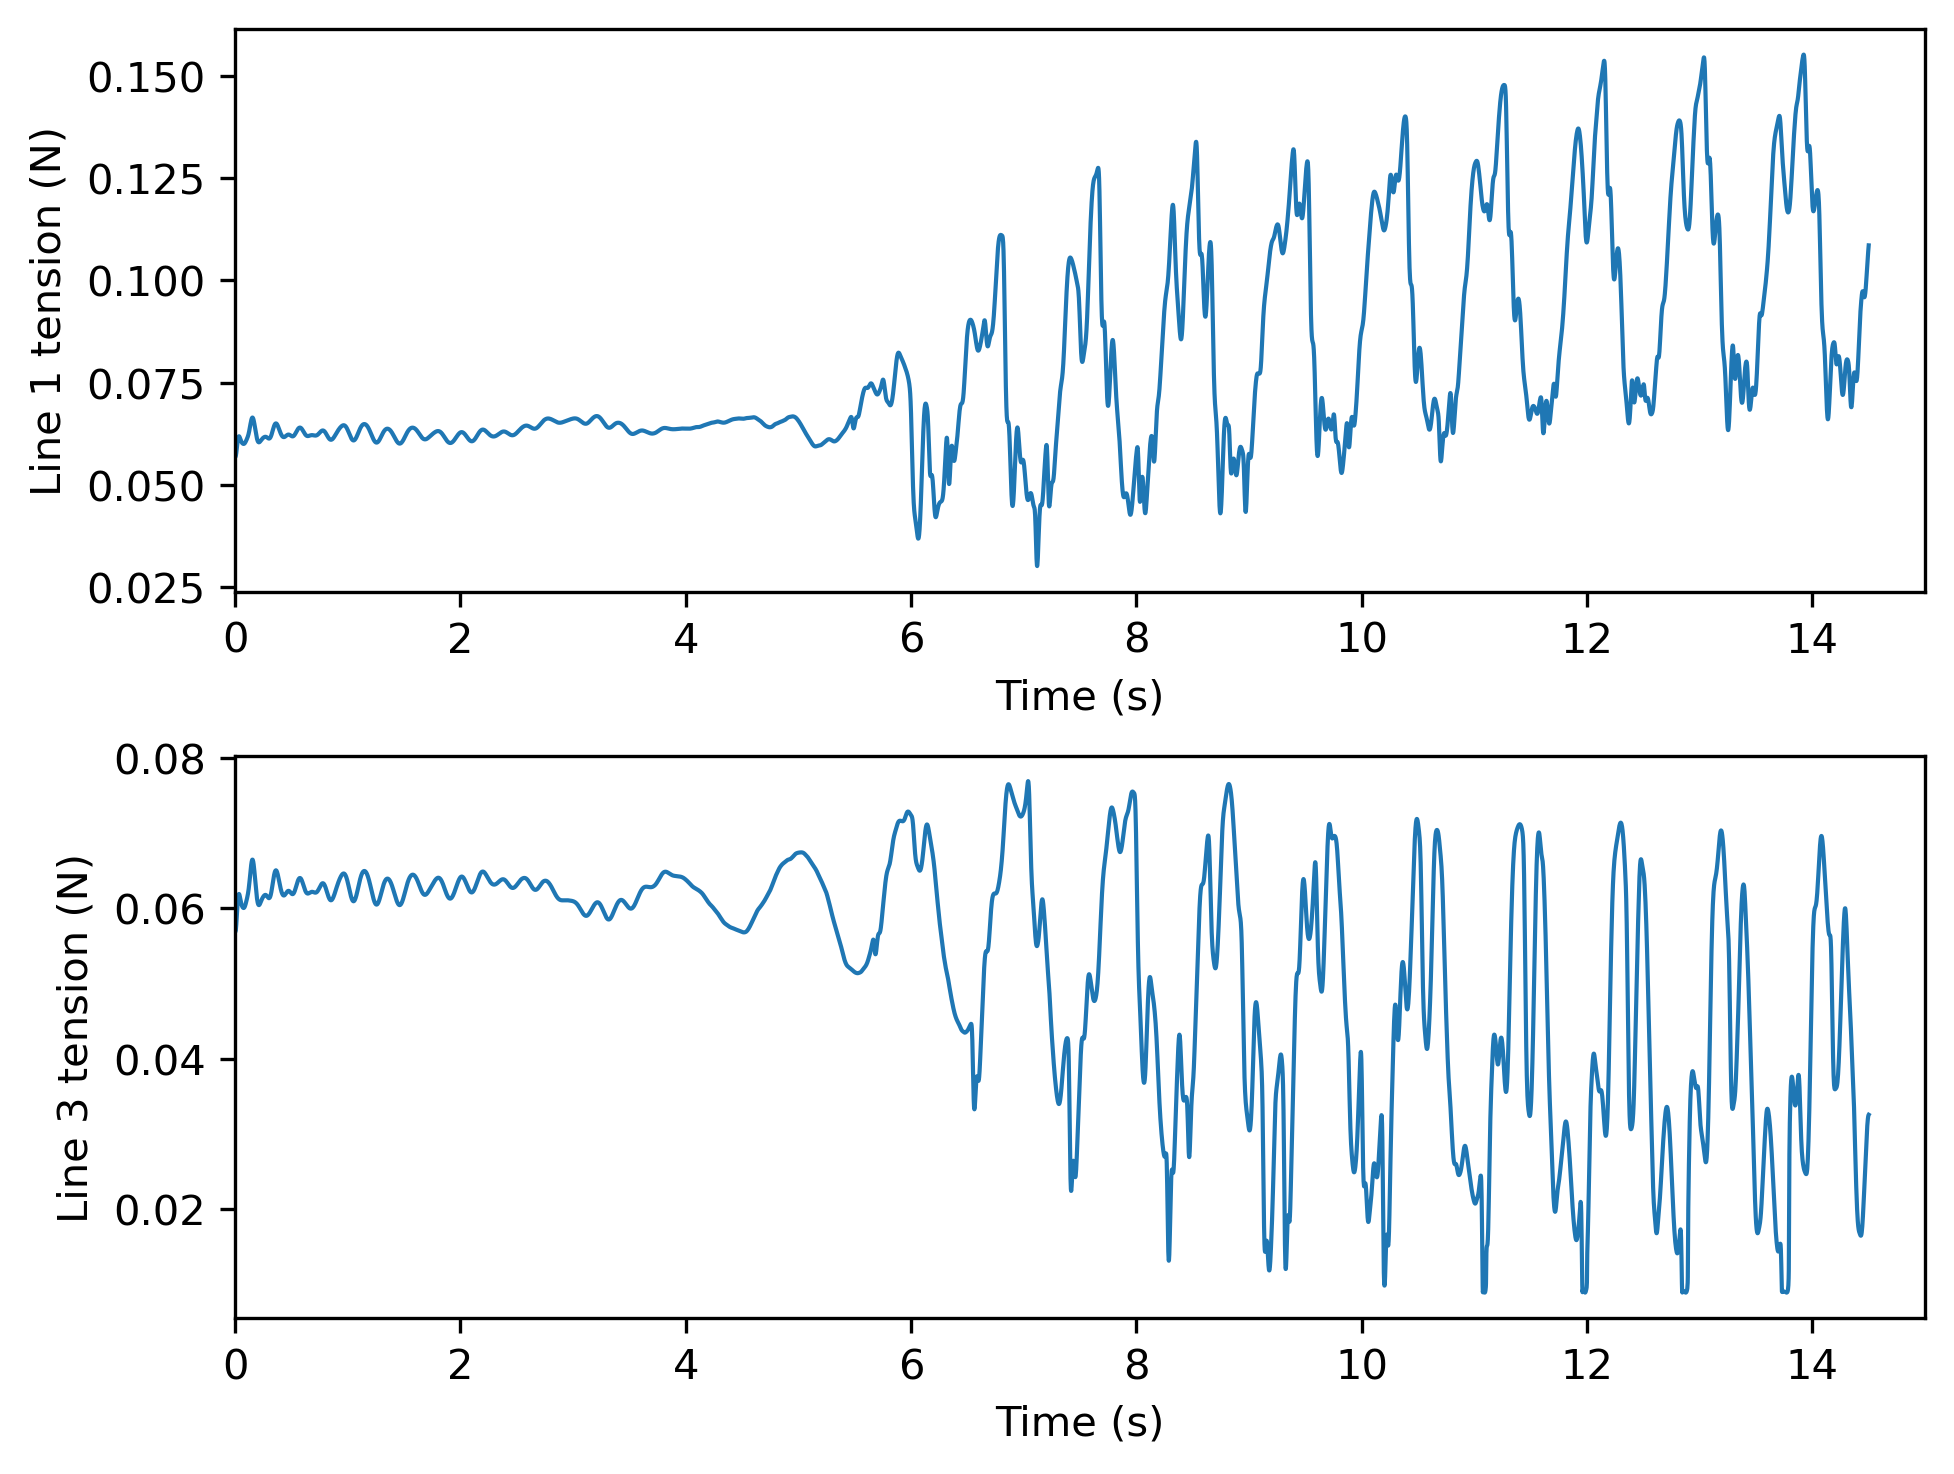

In [7]:
(time,FairTen1,FairTen3,AnchTen1,AnchTen3,L1N1pZ,L3N1pZ) = np.loadtxt('./Mooring/lines_v2_point.out', skiprows=2, unpack=True)

# Set figure and axes ...
fig1, (ax1, ax2) = plt.subplots(2, 1, dpi=300, layout='constrained')

# Plot ...
ax1.plot(time, AnchTen1, label="labels", linewidth=1)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Line 1 tension (N)');
ax1.set_xlim(0, np.ceil(time[-1]))
#ax1.set_ylim(0,1.5)

ax2.plot(time, AnchTen3, label="labels", linewidth=1)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Line 3 tension (N)');
ax2.set_xlim(0, np.ceil(time[-1]))
#ax2.set_ylim(0,1.5)

# Legends
#ax1.legend()
# Show the figure
plt.show()

fig1.savefig('./Plots/lineAnchTen.pdf', transparent=False, bbox_inches='tight')